# Soil Organic Carbon Dataset Download

In [2]:
# 🔄 Optional: Automatically reload imports if the source code changes
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import ee

ee.Authenticate()
ee.Initialize()

In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geemap as gm

sns.set_theme(style="whitegrid")
sns.set_context("talk")

# Import Local Data
Get all data that is alredy downloaded.

## Point Shapefile

In [6]:
path_to_soc_shp = './data/other_vectors/sichei_attr.shp'
path_to_soc_csv = './data/other_vectors/sichei_attr.csv'

# Load the shapefile
soc_gdf = gpd.read_file(path_to_soc_shp)

print(f'Columns GDF \n {soc_gdf.columns}')
print(f'Number of rows: {soc_gdf.shape[0]}')

soc = pd.read_csv(path_to_soc_csv)
print(f'Columns DF \n {soc.columns}')
print(f'Number of rows: {soc.shape[0]}')

soc.head()

Columns GDF 
 Index(['Site', 'Cluster', 'Plot', 'Depthcode', 'predSOC', 'Date', 'Latitude',
       'Longitude', 'Altitude', 'geometry'],
      dtype='object')
Number of rows: 319
Columns DF 
 Index(['Site', 'Cluster', 'Plot', 'Depthcode', 'predSOC', 'Date', 'Latitude',
       'Longitude', 'Altitude'],
      dtype='object')
Number of rows: 319


,Site,Cluster,Plot,Depthcode,predSOC,Date,Latitude,Longitude,Altitude
0,Sichei,1.0,1.0,Topsoil,11.246,10-Mar-21,0.711449,34.6406,1544.81
1,Sichei,1.0,1.0,Subsoil,8.619,10-Mar-21,0.711449,34.6406,1544.81
2,Sichei,2.0,1.0,Topsoil,11.516,11-Mar-21,0.731318,34.6339,1552.42
3,Sichei,2.0,1.0,Subsoil,9.866,11-Mar-21,0.731318,34.6339,1552.42
4,Sichei,3.0,1.0,Topsoil,14.464,12-Mar-21,0.768700,34.6443,1611.33


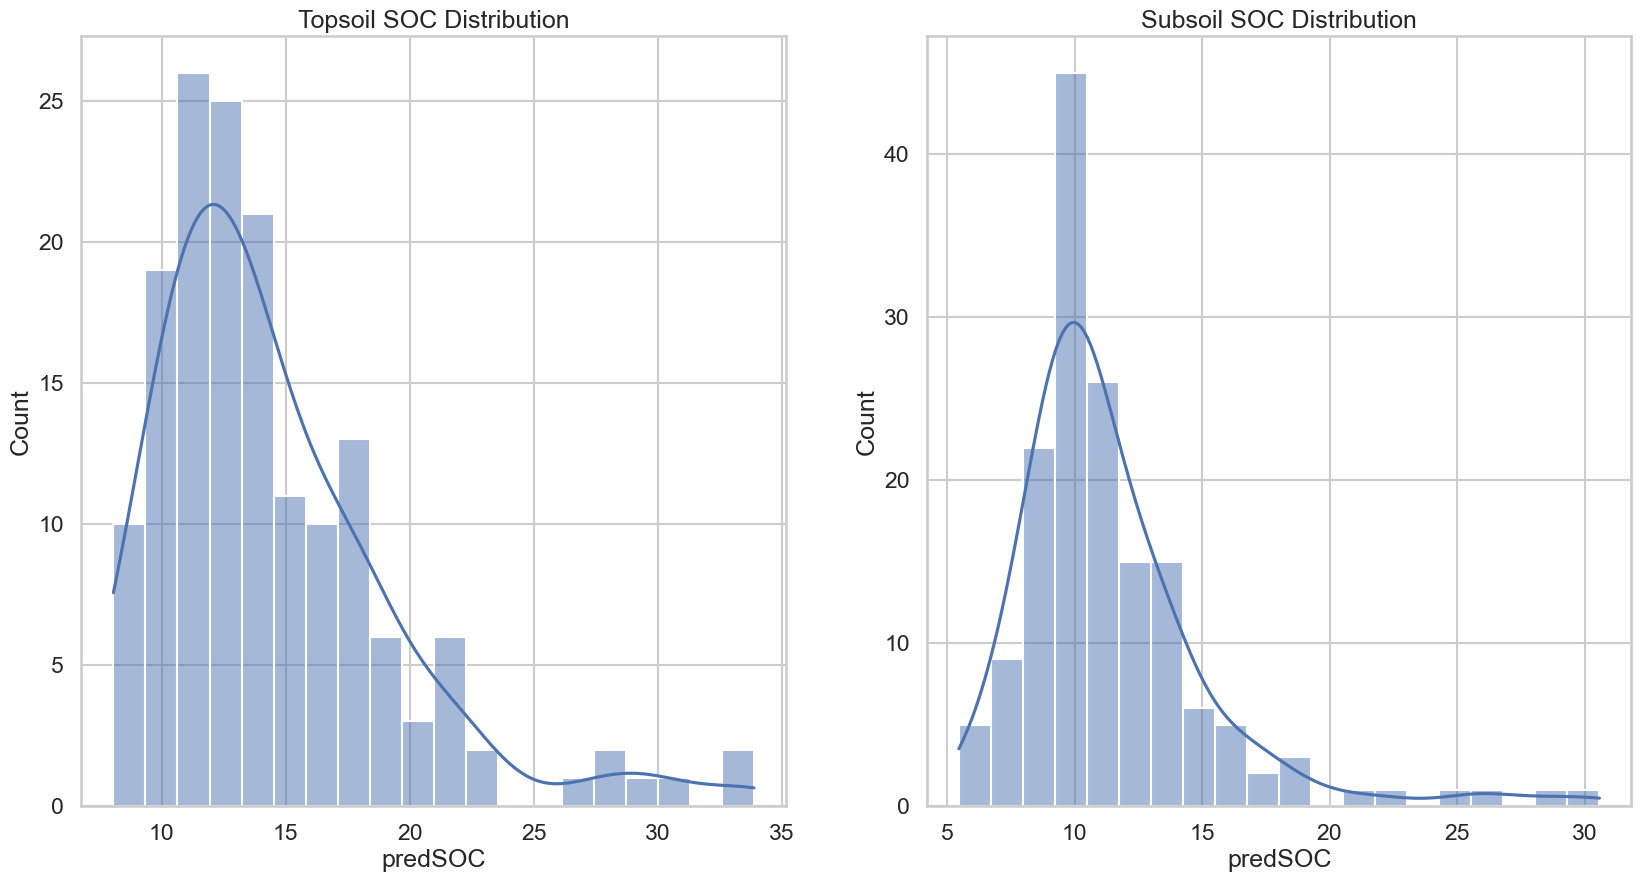

In [7]:
# Split into top and subsoil
topsoil = soc[soc['Depthcode'] == 'Topsoil']
subsoil = soc[soc['Depthcode'] == 'Subsoil']

# Plot the data
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(topsoil['predSOC'], bins=20, kde=True, ax=ax[0])
ax[0].set_title('Topsoil SOC Distribution')

sns.histplot(subsoil['predSOC'], bins=20, kde=True, ax=ax[1])
ax[1].set_title('Subsoil SOC Distribution')

plt.show()

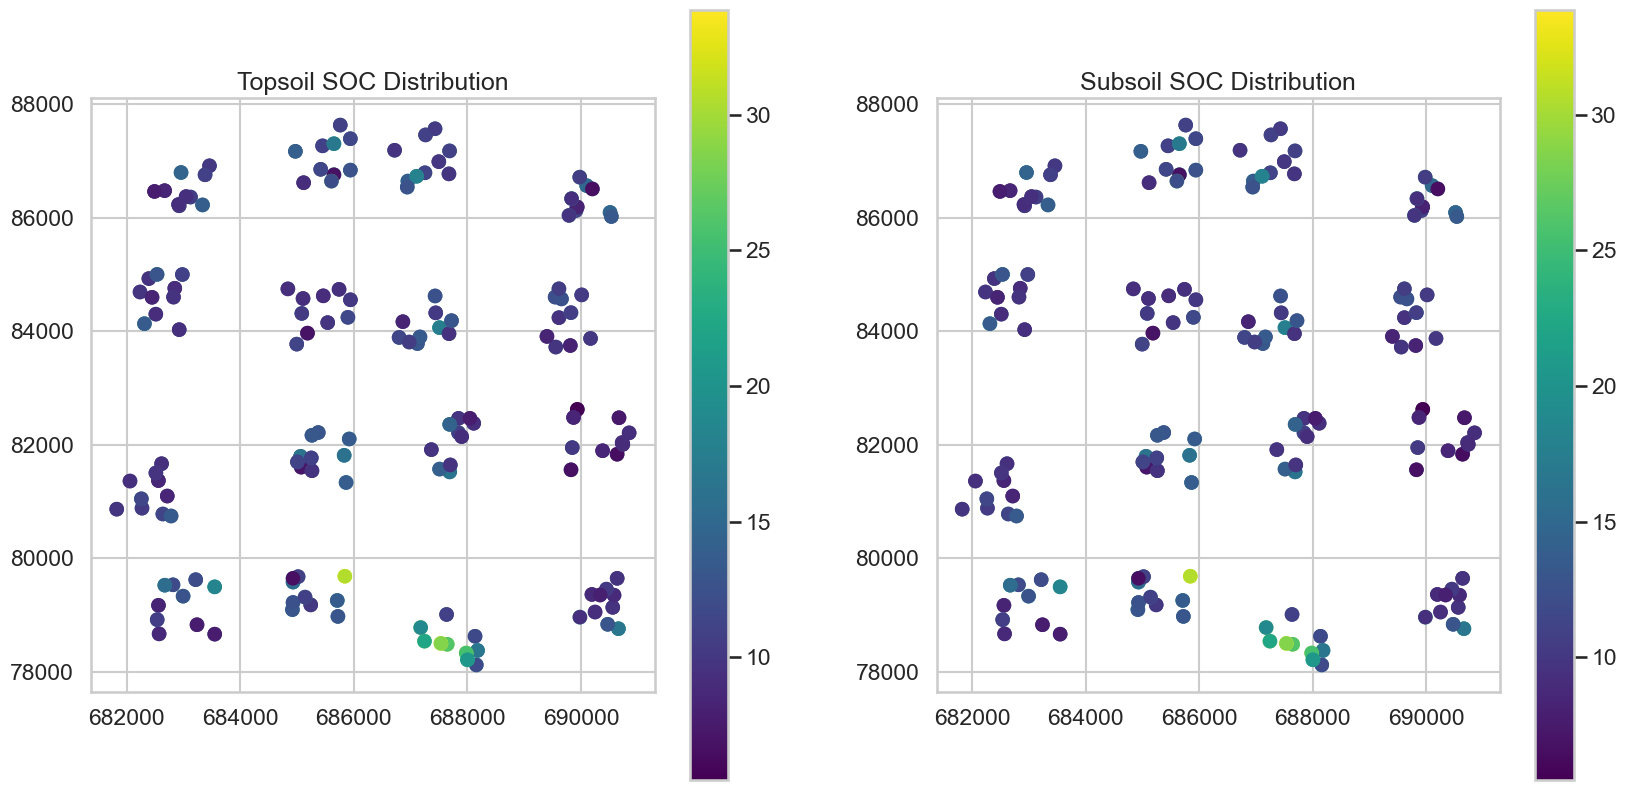

In [8]:
# Spatial Plot
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

soc_gdf.plot(column='predSOC', cmap='viridis', legend=True, ax=ax[0])
ax[0].set_title('Topsoil SOC Distribution')

soc_gdf.plot(column='predSOC', cmap='viridis', legend=True, ax=ax[1])
ax[1].set_title('Subsoil SOC Distribution')

plt.show()



In [9]:
# Merge the topsoil and subsoil data
soc_gdf = soc_gdf.pivot_table(index='geometry', values='predSOC', aggfunc='mean').reset_index()
soc_gdf = gpd.GeoDataFrame(soc_gdf, geometry='geometry')
soc_gdf.head()

,geometry,predSOC
0,POINT (682568.835 78668.993),9.9325
1,POINT (682535.352 78918.883),12.5035
2,POINT (682557.524 79171.778),9.4790
3,POINT (682668.709 79526.324),16.8675
4,POINT (682813.413 79533.121),15.0005


## The Bounding of the Data

Since I shall be getting data from Google Earth Engine using the python API, it is important to describe the bounding box of the dataset. 
This will be achieved by describing the extent of the data then, provinding a buffer of 2km around the extent. The resulting polygon will then be exported as the `bbox` of the region of study

In [10]:
from shapely.geometry import box
xmin, ymin, xmax, ymax = soc_gdf.total_bounds
bbox = box(xmin, ymin, xmax, ymax)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox], crs=soc_gdf.crs)
buffered_bbox_gdf = bbox_gdf.buffer(1000)
buffered_bbox_gdf = gpd.GeoDataFrame(geometry=buffered_bbox_gdf, crs=soc_gdf.crs)

# COnvert the bounding box to ee.Geometry
bbox_ee = gm.geopandas_to_ee(buffered_bbox_gdf)

buffered_bbox_gdf.to_file("./data/other_vectors/bbox.shp", driver='ESRI Shapefile')

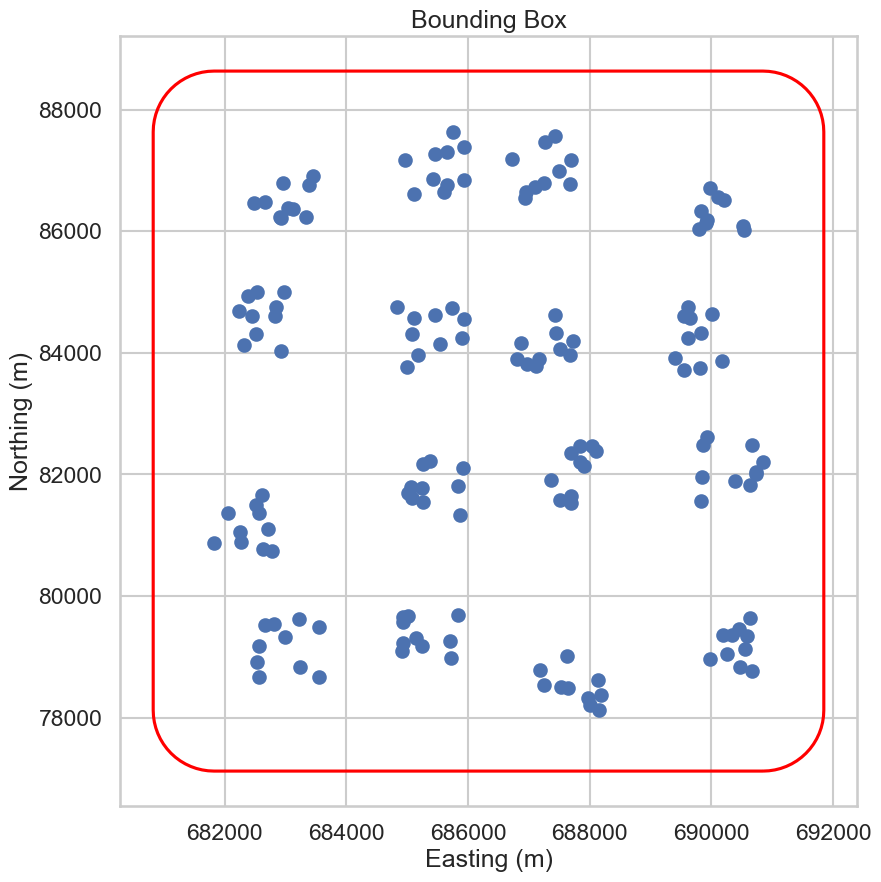

In [11]:
# Plot the bbox
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
soc_gdf.plot(ax=ax)
buffered_bbox_gdf.boundary.plot(ax=ax, color='red')
plt.title('Bounding Box')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)') 
plt.show()

# Dataset Processing

Data from Google Earth Engine for Predicting Soil Organic Carbon.  
The following datasets will be used in the study:
- Sentinel-1 (and Derivatives)
- Sentinel-2 (and Deivatives)
- Land Use Land Cover
- WAPOR Evapotranspiration
- Distance to Roads
- Distance to Rivers
- Lithology and Soil Types
- DEM and Derivatives (TWI, Curvature, Slope, Stream Power Index)

### Sentinel 1 RADAR Data 
Collection of SAR data from the COPERNICUS collection

In [12]:
def mask_edge(image):
    edge = image.lt(-30.0)
    masked_image = image.mask().And(edge.Not())
    return image.updateMask(masked_image)

In [13]:
img_vv_vh = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .select(['VV','VH'])  
    .map(mask_edge)
)

focus_date = ee.Filter.date('2021-03-01', '2021-03-20')
img_mean = img_vv_vh.filter(focus_date).mean().clip(bbox_ee)

### Sentinel 1 SAR Derivatives 

The indices of sentinel-1 can be used to give insight into subsurface properties. 
The following indices will be computed:
-  VH/VV Ratio (VVVHR)
    > This index helps to understand soil moisture and surface roughness, which are correlated with SOC.
    $$
    VVVH R = \frac{VV}{VH}
    $$

- Radar Vegetation Index
    $$
    RVI = \frac{4 *VH}{VV+VH}
    $$
- Normalized Difference Index
    $$
    NDI = \frac{VV-VH}{VV+VH}
    $$
- Cross-Polarization Ratio  
    ​$$
    CPR = \frac{VH}{VV}
    $$


In [14]:
# import Sentinel1SARIndices class
from soc_scripts.gee_functions import Sentinel1SARIndices

# Instantiate the class with the Sentinel-1 image
sar_indices = Sentinel1SARIndices(img_mean)

# Apply all indices
processed_image = sar_indices.apply_all_indices()

In [ ]:
from soc_scripts.extraction import stack_rasters
# Convert FeatureCollection to Geometry if needed
bbox_ee = bbox_ee.geometry() if isinstance(bbox_ee, ee.FeatureCollection) else bbox_ee

# Export the Image to local directory
filename = './data/exports/s1/sentinel1.tif'

gm.ee_export_image(
    processed_image, 
    filename=filename, 
    scale=20, 
    region=bbox_ee, 
    file_per_band=True,
    crs='EPSG:32636'
    )
# stack_rasters('./data/exports/s1', 'sentinel1_stack.tif')

Generating URL ...
Please wait ...
Data downloaded to c:\Users\roywaswa\PROJECTS\Data-Science\02-SOC\exports\s1


In [14]:
sarMap = gm.Map()
sarMap.center_object(bbox_ee, 12)
sarMap.add_layer(img_mean, {'min': -25, 'max': 5}, 'Multi-T Mean ASC', True)
sarMap

Map(center=[0.7494919277365318, 34.67445436967993], controls=(WidgetControl(options=['position', 'transparent_…

In [15]:
# Sample the data from the image using the points from the shapefile
soc_points = gm.geopandas_to_ee(soc_gdf)

socsoil_points = img_mean.sampleRegions(
    collection=soc_points,
    scale=10,
    geometries=True
)

### Sentinel 2 MSI Data


In [16]:
def mask_s2_clouds(image):
    """Masks clouds in a Sentinel-2 image using the QA band.

    Args:
        image (ee.Image): A Sentinel-2 image.

    Returns:
        ee.Image: A cloud-masked Sentinel-2 image.
    """
    qa = image.select('QA60')

    # Bits 10 and 11 are clouds and cirrus, respectively.
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    # Both flags should be set to zero, indicating clear conditions.
    mask = (
        qa.bitwiseAnd(cloud_bit_mask)
        .eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )

    return image.updateMask(mask).divide(10000)


dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2021-03-01', '2021-04-01')
    # Pre-filter to get less cloudy granules.
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
    .select(['B2', 'B3', 'B4','B5','B6','B7','B8', 'B8A','B9', 'B11', 'B12']) 
    .mean().clip(bbox_ee)
)


### Sentinel-2 Indices for Soil Organic Carbon Estimation

Sentinel-2 provides multispectral imagery that is useful for estimating Soil Organic Carbon (SOC). Several vegetation and soil indices derived from Sentinel-2 bands can be correlated with SOC.

#### 1. Normalized Difference Vegetation Index (NDVI)
NDVI is commonly used to assess vegetation health and biomass, both of which are linked to SOC.

$$
NDVI = \frac{B8 - B4}{B8 + B4}
$$

#### 2. Normalized Difference Soil Index (NDSI)
NDSI helps distinguish bare soil from vegetation and can be useful in SOC estimation.

$$
NDSI = \frac{B11 - B4}{B11 + B4}
$$

#### 3. Soil Adjusted Vegetation Index (SAVI)
SAVI accounts for soil brightness and is useful in semi-arid and arid regions.

$$
SAVI = \frac{(B8 - B4) \times (1 + L)}{B8 + B4 + L}
$$

where \( L \) is a soil brightness correction factor (typically 0.5).

#### 4. Bare Soil Index (BSI)
BSI helps in detecting bare soil areas, which are important for SOC estimation.

$$
BSI = \frac{(B11 + B4) - (B8 + B2)}{(B11 + B4) + (B8 + B2)}
$$

#### 5. Normalized Burn Ratio (NBR)
NBR is useful for assessing soil conditions after disturbances such as wildfires, which influence SOC.

$$
NBR = \frac{B8 - B12}{B8 + B12}
$$

These indices provide valuable insights into vegetation, soil properties, and moisture levels, all of which are essential for estimating Soil Organic Carbon (SOC). They can be used in combination with machine learning models or regression analyses for SOC prediction.




In [ ]:
from soc_scripts.gee_functions import Sentinel2Indices
# Instantiate the class with the Sentinel-2 image
s2_indices = Sentinel2Indices(dataset)
# Apply all indices
processed_s2_image = s2_indices.apply_all_indices()
# Get the processed image information
processed_s2_image.getInfo()


In [ ]:
from soc_scripts.extraction import stack_rasters
# Convert FeatureCollection to Geometry if needed
bbox_ee = bbox_ee.geometry() if isinstance(bbox_ee, ee.FeatureCollection) else bbox_ee

# Export the Image to local directory
filename = './data/exports/s2/sentinel2.tif'

gm.ee_export_image(
    processed_s2_image, 
    filename=filename, 
    scale=20, 
    region=bbox_ee, 
    file_per_band=True,
    crs='EPSG:32636'
    )

Generating URL ...
Please wait ...
Data downloaded to c:\Users\roywaswa\PROJECTS\Data-Science\02-SOC\exports\s2


In [ ]:
# stack_rasters('./data/exports/s2', 'sentinel2_stack.tif')

In [20]:

visualization = {
    'min': 0.0,
    'max': 0.3,
    'bands': ['B4', 'B3', 'B2'],
}

m = gm.Map()
m.center_object(bbox_ee, 12)
m.add_layer(dataset, visualization, 'RGB')
m

Map(center=[0.7494919277365318, 34.67445436967993], controls=(WidgetControl(options=['position', 'transparent_…

### Raster Datasets
Obtaining the rest of the data from local raster files:
- apsect
- slope
- curvature
- twi
- strm
- distance from rivers
- distance from roads
- soil types (SOTER)

In [ ]:
from soc_scripts.extraction import sample_rasters_at_points
# Sample the rasters at the points
sentinel_rasters= {
    's2_B2': './data/exports/s2/sentinel2.B2.tif',
    's2_B3': './data/exports/s2/sentinel2.B3.tif',
    's2_B4': './data/exports/s2/sentinel2.B4.tif',
    's2_B5': './data/exports/s2/sentinel2.B5.tif',
    's2_B6': './data/exports/s2/sentinel2.B6.tif',
    's2_B7': './data/exports/s2/sentinel2.B7.tif',
    's2_B8': './data/exports/s2/sentinel2.B8.tif',
    's2_B8A': './data/exports/s2/sentinel2.B8A.tif',
    's2_B9': './data/exports/s2/sentinel2.B9.tif',
    's2_B11': './data/exports/s2/sentinel2.B11.tif',
    's2_B12': './data/exports/s2/sentinel2.B12.tif',
    's2_BSI': './data/exports/s2/sentinel2.BSI.tif',
    's2_NDVI': './data/exports/s2/sentinel2.NDVI.tif',
    's2_NBR': './data/exports/s2/sentinel2.NBR.tif',
    's2_NDSI': './data/exports/s2/sentinel2.NDSI.tif',
    's2_SAVI': './data/exports/s2/sentinel2.SAVI.tif',
    's1_VV': './data/exports/s1/sentinel1.VV.tif',
    's1_VH': './data/exports/s1/sentinel1.VH.tif',
    's1_RVI': './data/exports/s1/sentinel1.RVI.tif',
    's1_NDI': './data/exports/s1/sentinel1.NDI.tif',
    's1_CPR': './data/exports/s1/sentinel1.CPR.tif',
    's1_VVVHR': './data/exports/s1/sentinel1.VVVHR.tif',
}
constants_dict = {
    'aspect': './data/rasters/aspect_sichei.tif',
    'slope': './data/rasters/slope_sichei.tif',
    'curvature': './data/rasters/curvature_sichei.tif',
    'twi': './data/rasters/model_twi.tif',
    'elevation': './data/rasters/srtm_30.tif',
    'rivers_distance': './data/rasters/rivers_distance_sichei.tif',
    'roads_distance': './data/rasters/roads_distances_sichei.tif',
}
# Combine all rasters into a single dictionary
all_rasters = {**sentinel_rasters, **constants_dict}
all_rasters

{'s2_B2': './exports/s2/sentinel2.B2.tif',
 's2_B3': './exports/s2/sentinel2.B3.tif',
 's2_B4': './exports/s2/sentinel2.B4.tif',
 's2_B5': './exports/s2/sentinel2.B5.tif',
 's2_B6': './exports/s2/sentinel2.B6.tif',
 's2_B7': './exports/s2/sentinel2.B7.tif',
 's2_B8': './exports/s2/sentinel2.B8.tif',
 's2_B8A': './exports/s2/sentinel2.B8A.tif',
 's2_B9': './exports/s2/sentinel2.B9.tif',
 's2_B11': './exports/s2/sentinel2.B11.tif',
 's2_B12': './exports/s2/sentinel2.B12.tif',
 's2_BSI': './exports/s2/sentinel2.BSI.tif',
 's2_NDVI': './exports/s2/sentinel2.NDVI.tif',
 's2_NBR': './exports/s2/sentinel2.NBR.tif',
 's2_NDSI': './exports/s2/sentinel2.NDSI.tif',
 's2_SAVI': './exports/s2/sentinel2.SAVI.tif',
 's1_VV': './exports/s1/sentinel1.VV.tif',
 's1_VH': './exports/s1/sentinel1.VH.tif',
 's1_RVI': './exports/s1/sentinel1.RVI.tif',
 's1_NDI': './exports/s1/sentinel1.NDI.tif',
 's1_CPR': './exports/s1/sentinel1.CPR.tif',
 's1_VVVHR': './exports/s1/sentinel1.VVVHR.tif',
 'aspect': './raster

In [68]:
sampled_data = sample_rasters_at_points(soc_gdf, all_rasters)
sampled_data.head()

Sampling s2_B2 from ./exports/s2/sentinel2.B2.tif
Sampling s2_B3 from ./exports/s2/sentinel2.B3.tif
Sampling s2_B4 from ./exports/s2/sentinel2.B4.tif
Sampling s2_B5 from ./exports/s2/sentinel2.B5.tif
Sampling s2_B6 from ./exports/s2/sentinel2.B6.tif
Sampling s2_B7 from ./exports/s2/sentinel2.B7.tif
Sampling s2_B8 from ./exports/s2/sentinel2.B8.tif
Sampling s2_B8A from ./exports/s2/sentinel2.B8A.tif
Sampling s2_B9 from ./exports/s2/sentinel2.B9.tif
Sampling s2_B11 from ./exports/s2/sentinel2.B11.tif
Sampling s2_B12 from ./exports/s2/sentinel2.B12.tif
Sampling s2_BSI from ./exports/s2/sentinel2.BSI.tif
Sampling s2_NDVI from ./exports/s2/sentinel2.NDVI.tif
Sampling s2_NBR from ./exports/s2/sentinel2.NBR.tif
Sampling s2_NDSI from ./exports/s2/sentinel2.NDSI.tif
Sampling s2_SAVI from ./exports/s2/sentinel2.SAVI.tif
Sampling s1_VV from ./exports/s1/sentinel1.VV.tif
Sampling s1_VH from ./exports/s1/sentinel1.VH.tif
Sampling s1_RVI from ./exports/s1/sentinel1.RVI.tif
Sampling s1_NDI from ./exp

,geometry,predSOC,s2_B2,s2_B3,s2_B4,s2_B5,s2_B6,s2_B7,s2_B8,s2_B8A,...,s1_NDI,s1_CPR,s1_VVVHR,aspect,slope,curvature,twi,elevation,rivers_distance,roads_distance
0,POINT (682568.835 78668.993),9.9325,0.047633,0.080433,0.085600,0.136800,0.224033,0.253400,0.255600,0.277967,...,-0.181094,1.442283,1.442283,116.565048,2.078012,-0.105323,7.437472,1560.0,990.223694,126.301727
1,POINT (682535.352 78918.883),12.5035,0.054300,0.085600,0.104333,0.159800,0.224500,0.256033,0.261733,0.281833,...,-0.180307,1.439939,1.439939,45.000000,2.627810,-0.000000,6.509323,1562.0,921.653076,82.789207
2,POINT (682557.524 79171.778),9.4790,0.051767,0.082733,0.087833,0.136300,0.239200,0.272267,0.278267,0.296500,...,-0.352759,2.090037,2.090037,30.963757,2.708566,-0.000000,8.963918,1556.0,722.070557,57.369698
3,POINT (682668.709 79526.324),16.8675,0.047433,0.077267,0.083733,0.133900,0.223500,0.260400,0.261267,0.273600,...,-0.158960,1.378009,1.378009,90.000000,1.858794,-0.000000,7.954509,1544.0,346.116974,0.000000
4,POINT (682813.413 79533.121),15.0005,0.049533,0.083367,0.077867,0.132867,0.234000,0.268400,0.281667,0.291567,...,-0.204034,1.512671,1.512671,57.528809,3.027705,0.105323,6.367439,1542.0,292.126770,131.545120


In [ ]:
sampled_data.to_csv('./data/exports/sampled_data.csv', index=False)

#### Distribution Visualization

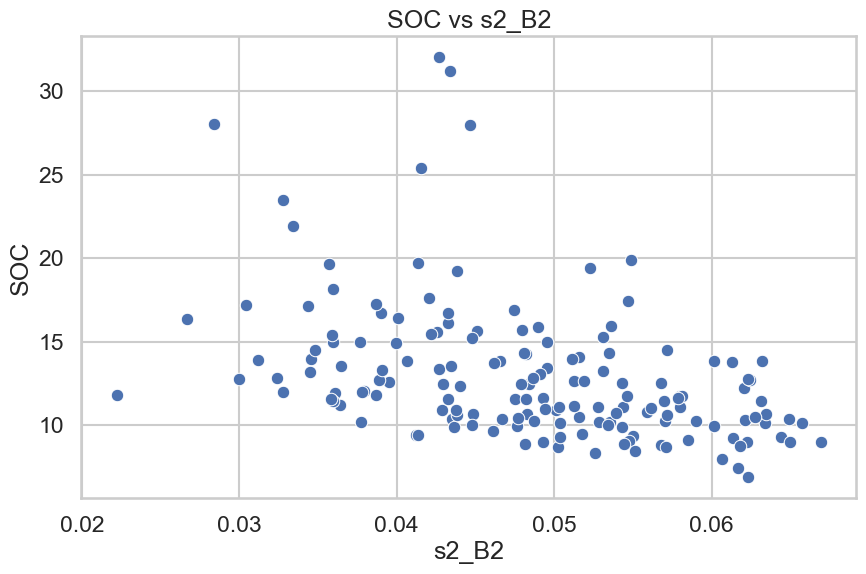

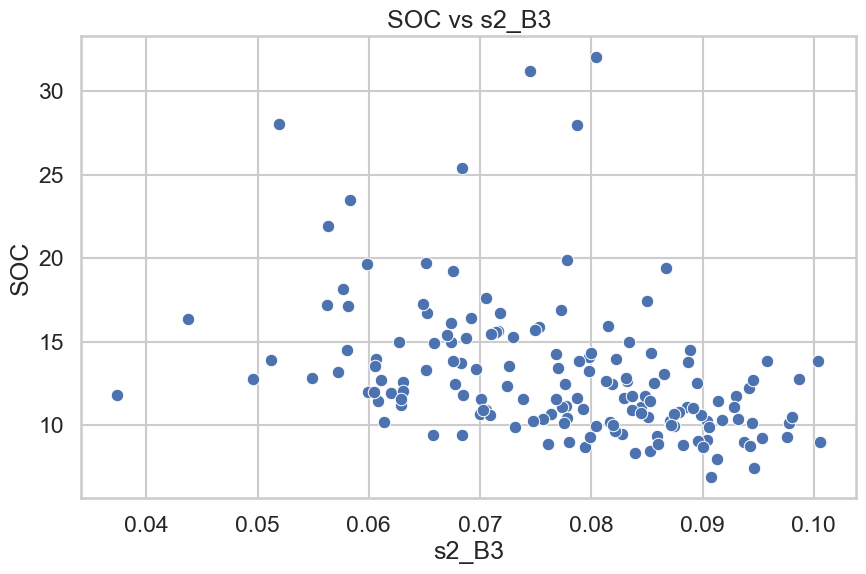

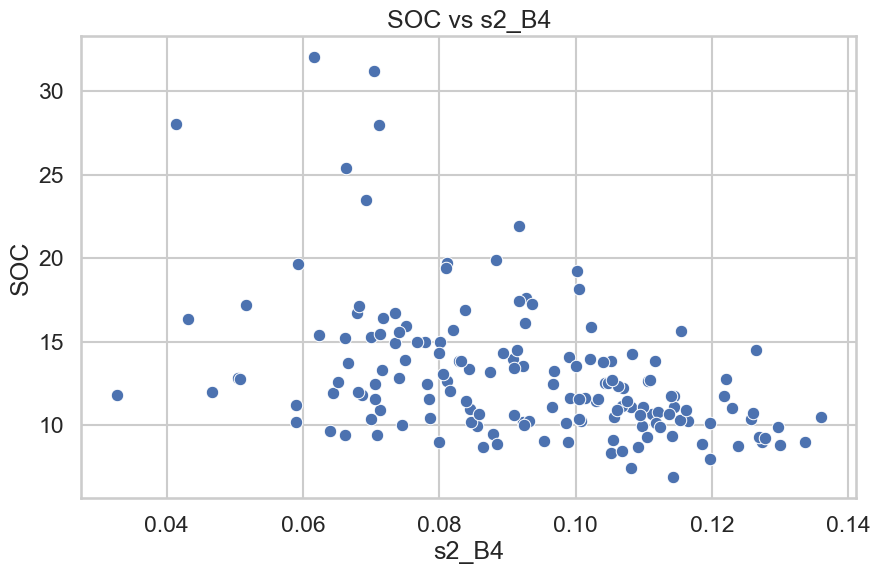

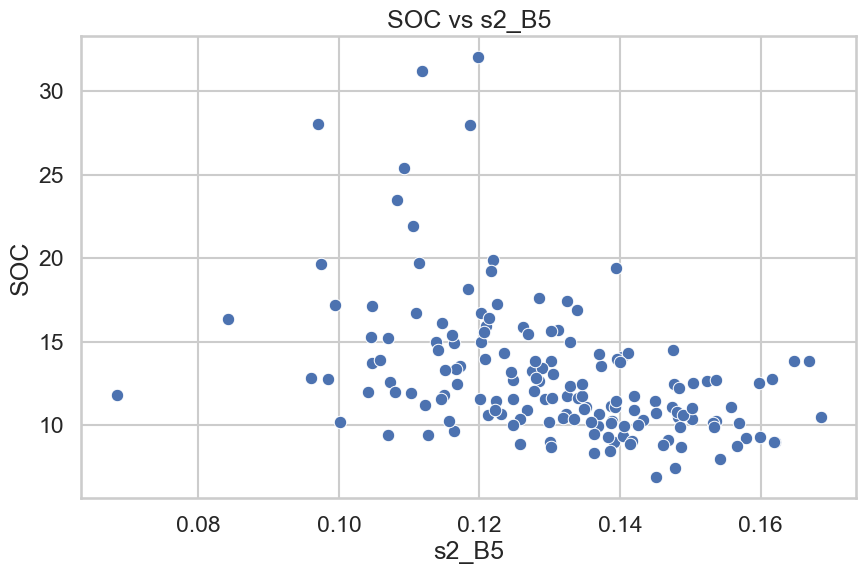

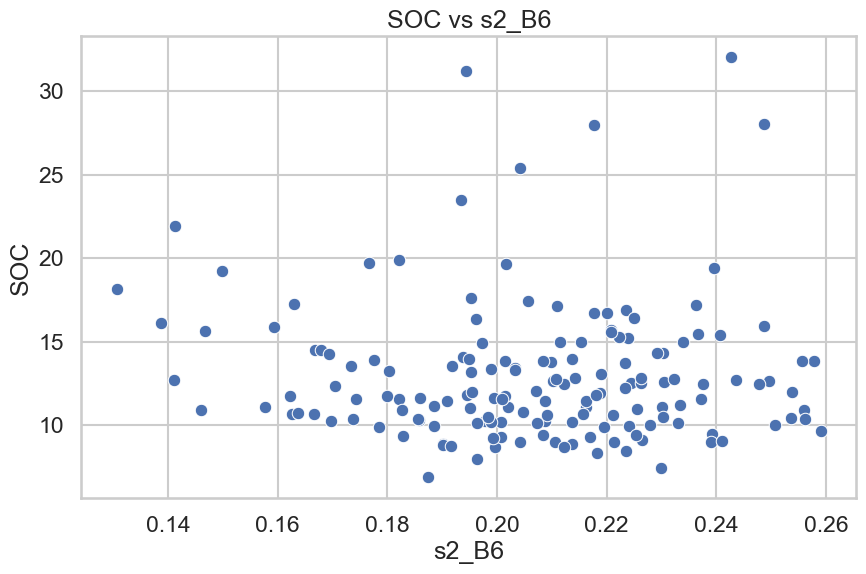

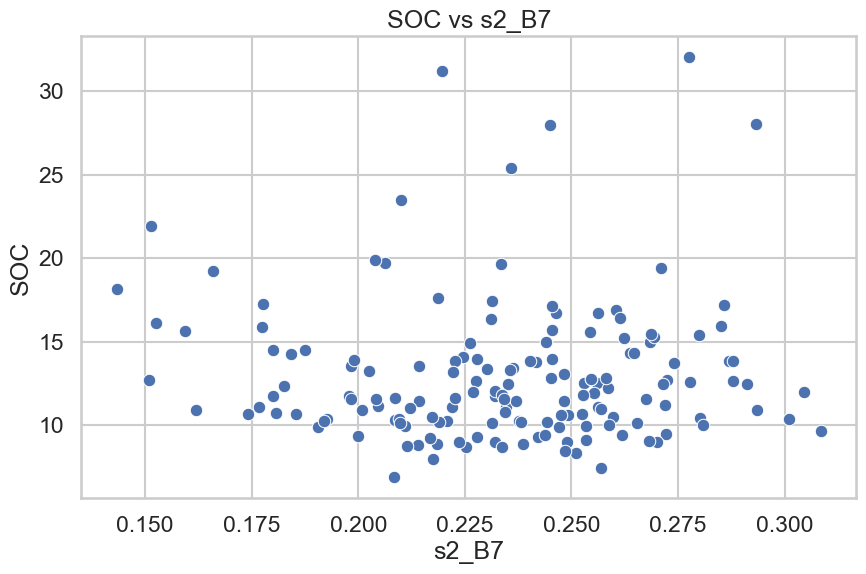

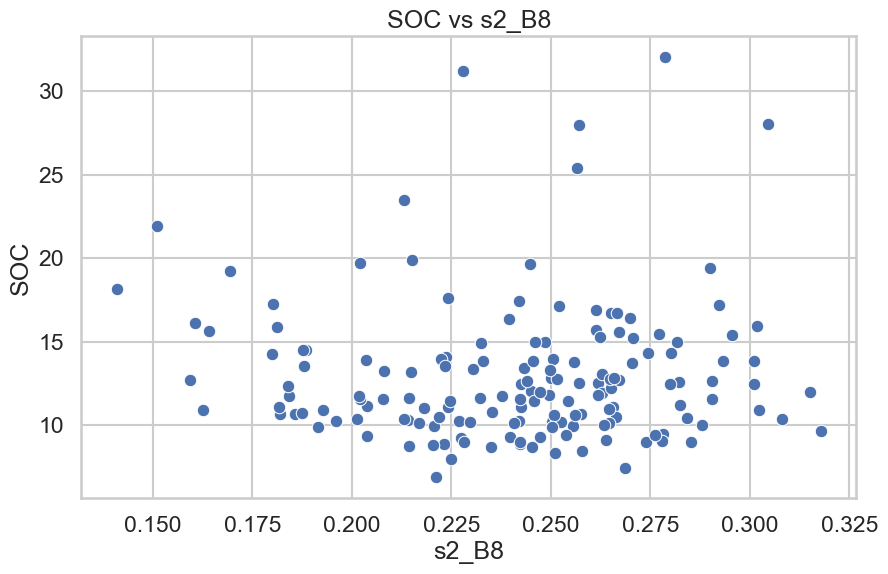

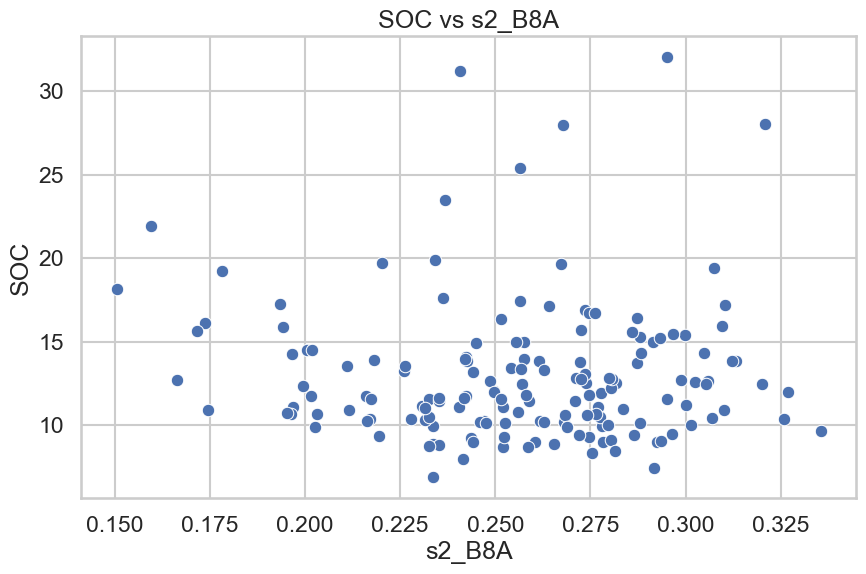

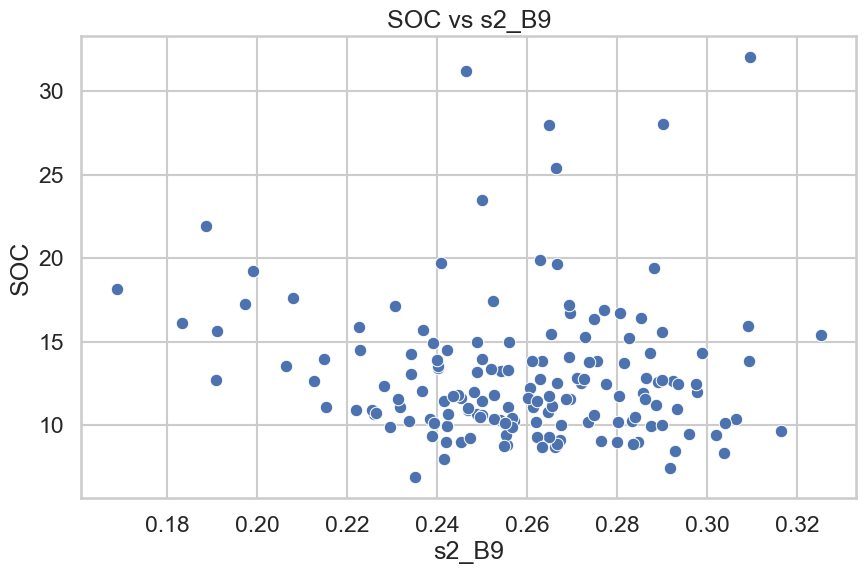

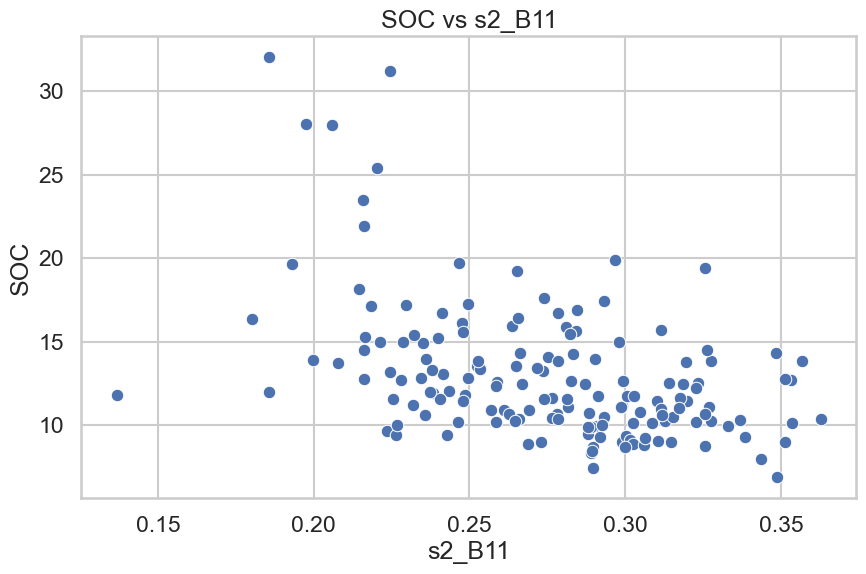

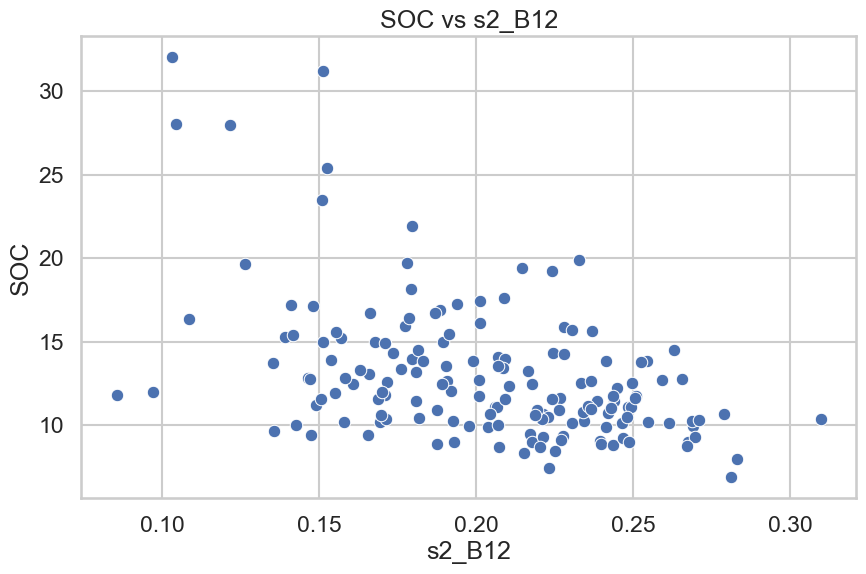

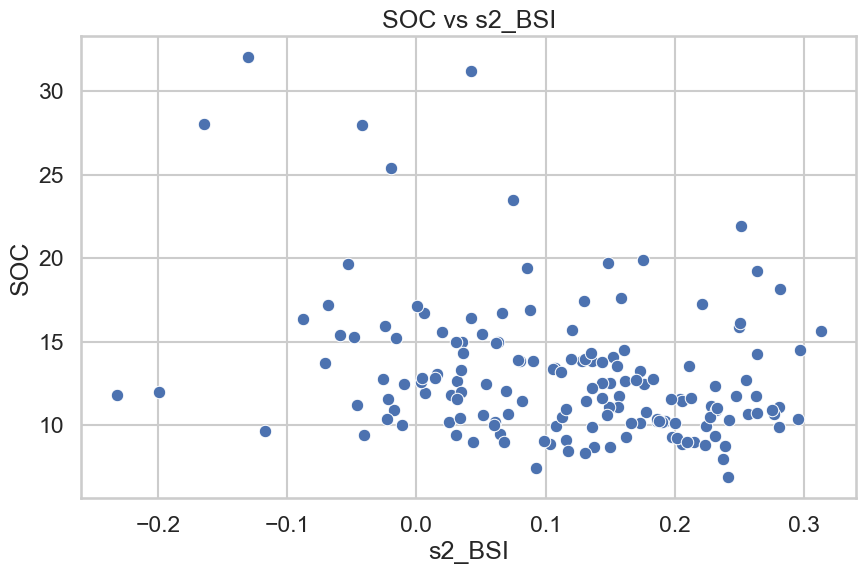

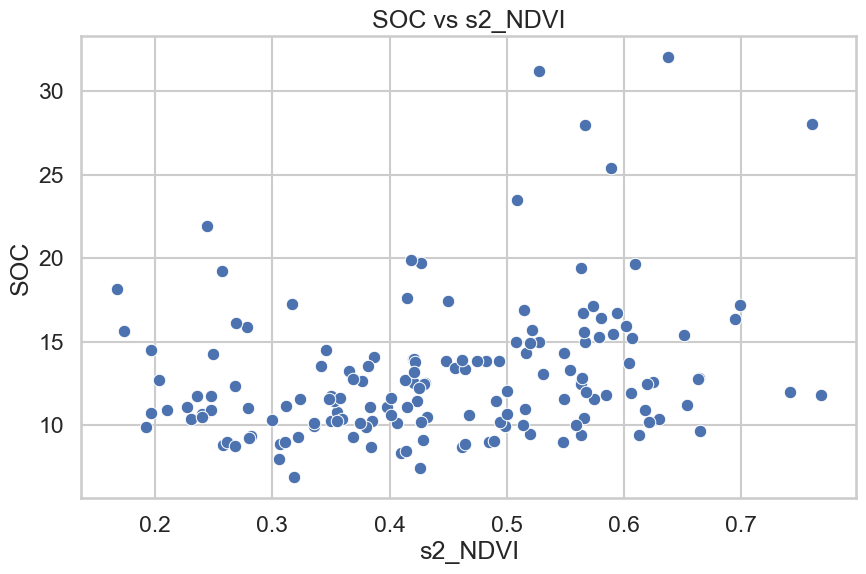

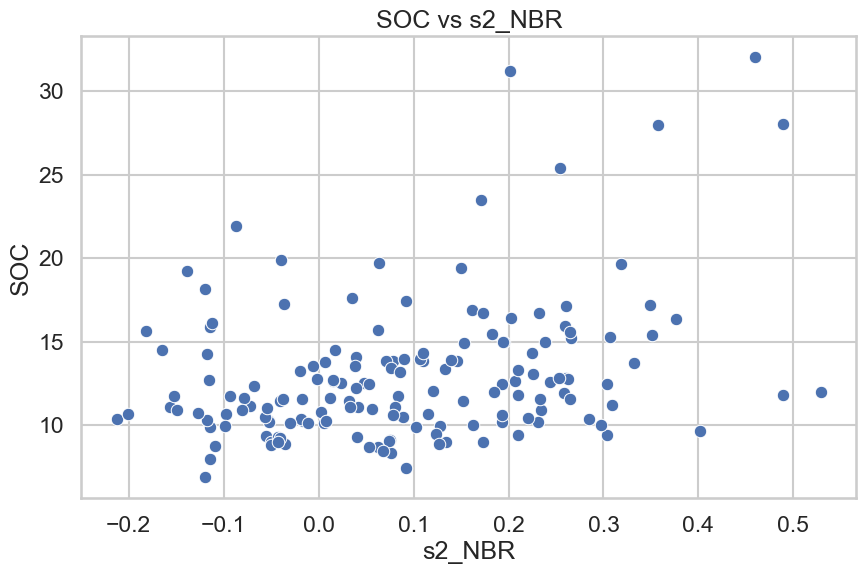

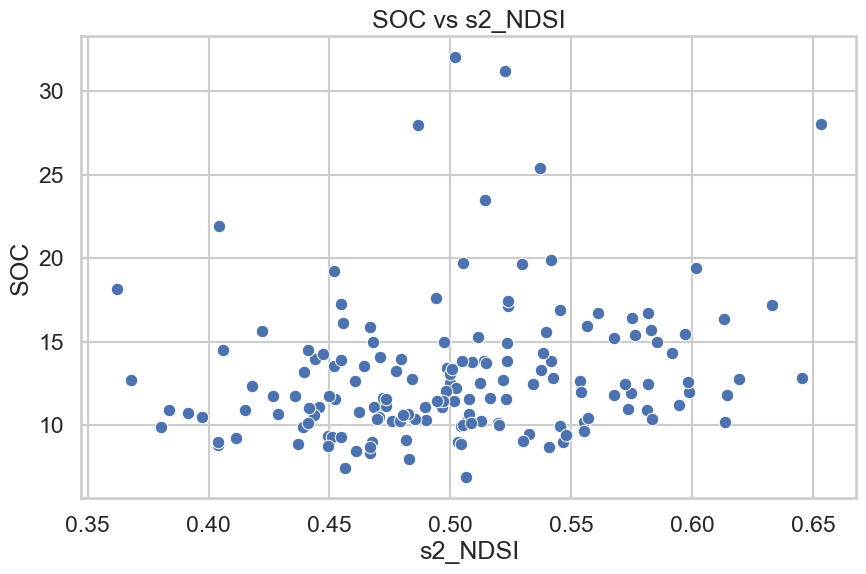

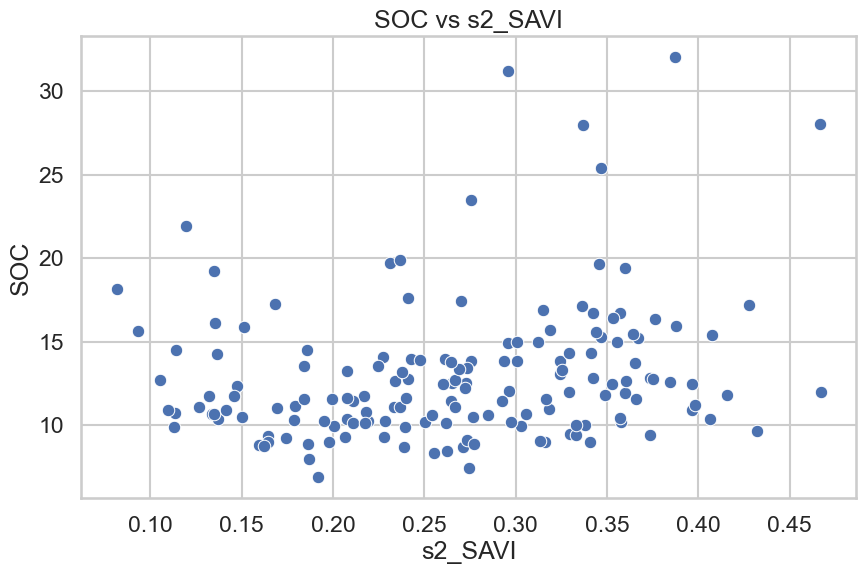

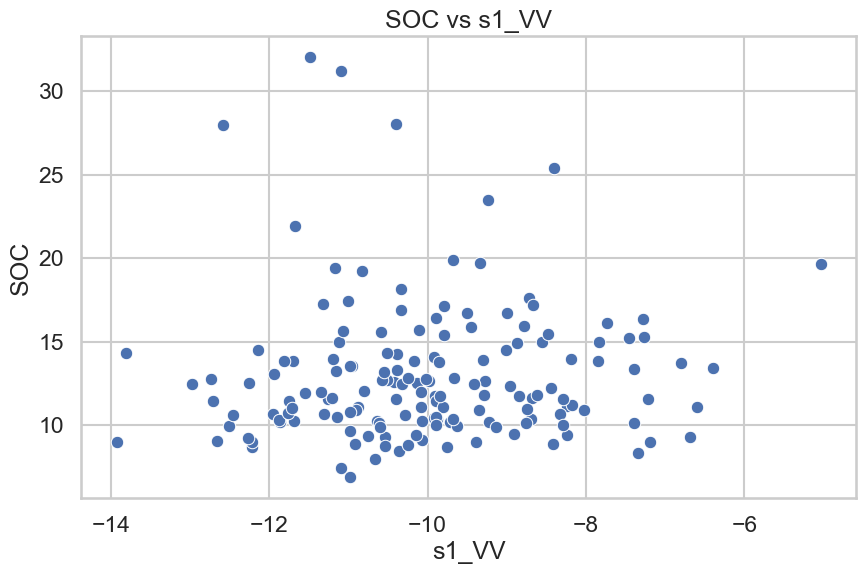

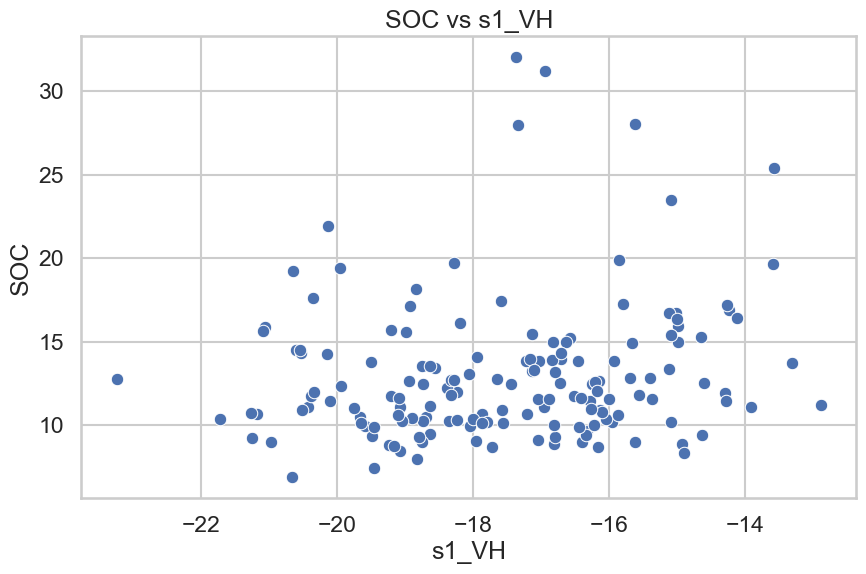

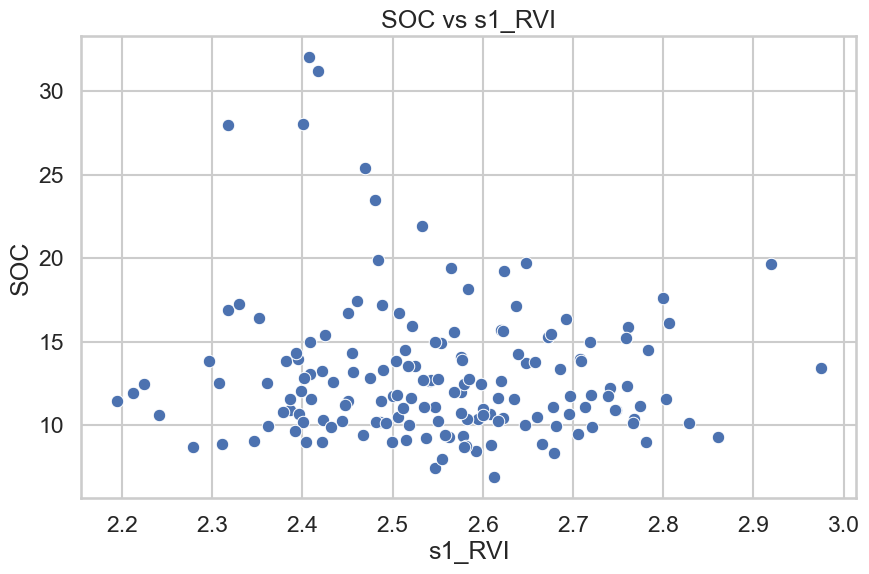

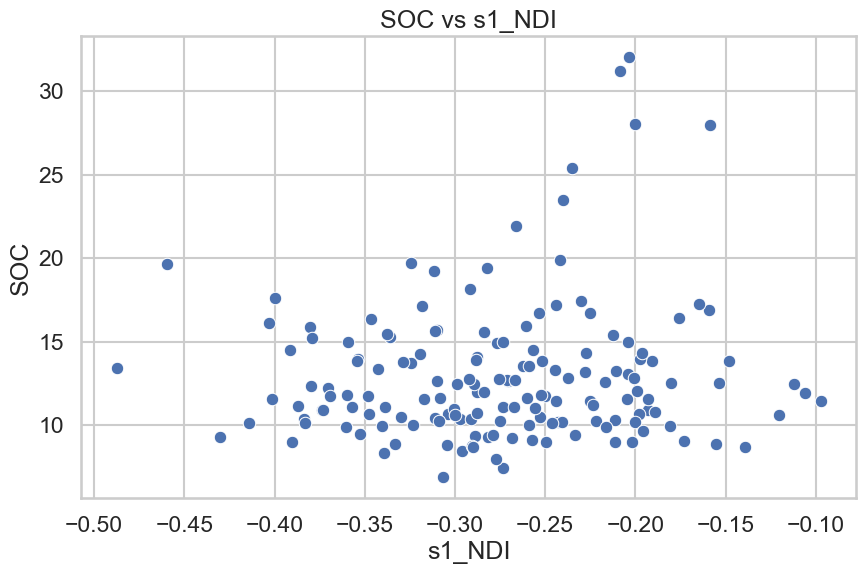

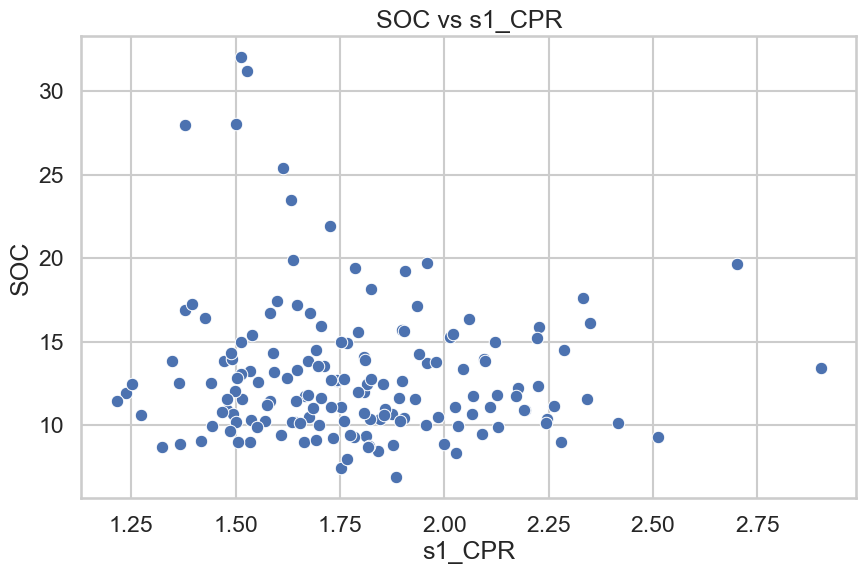

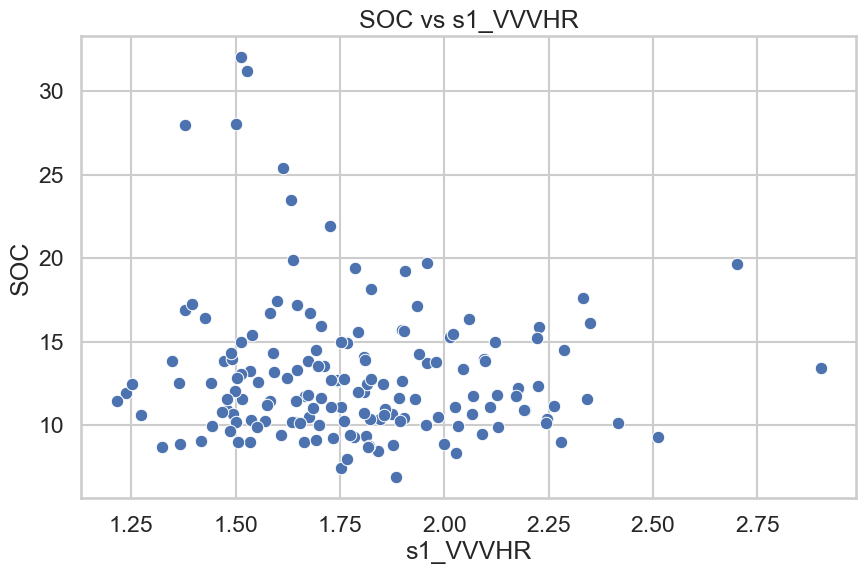

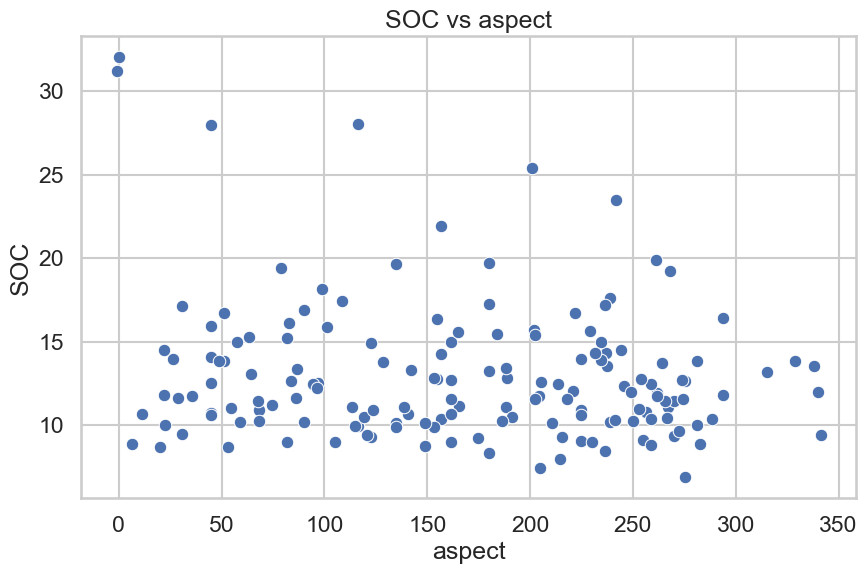

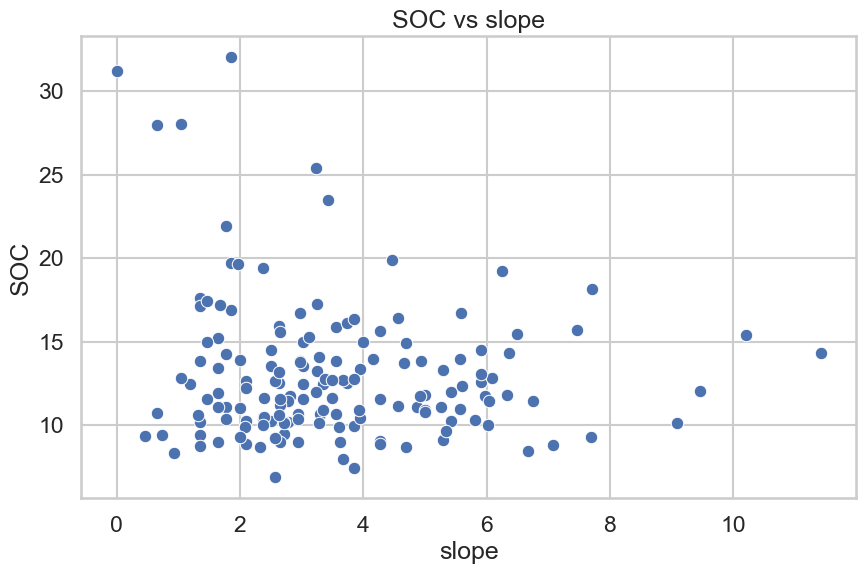

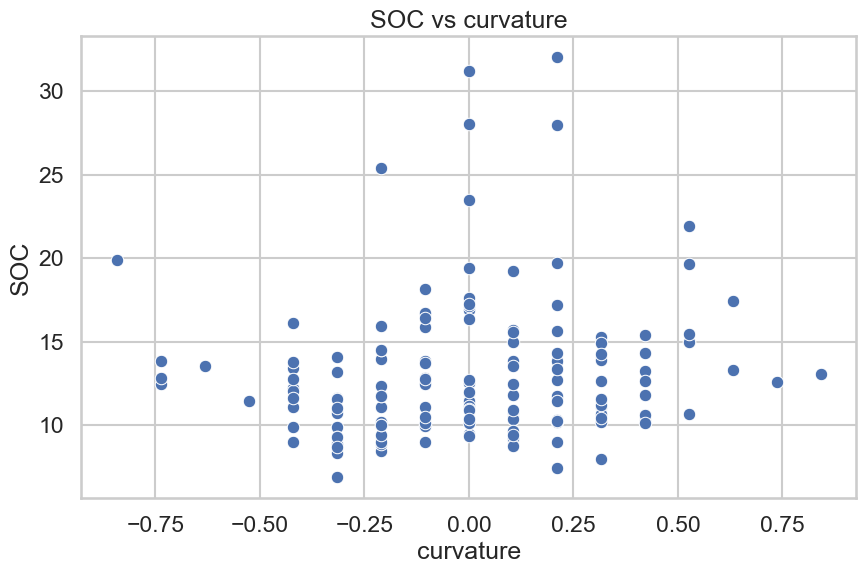

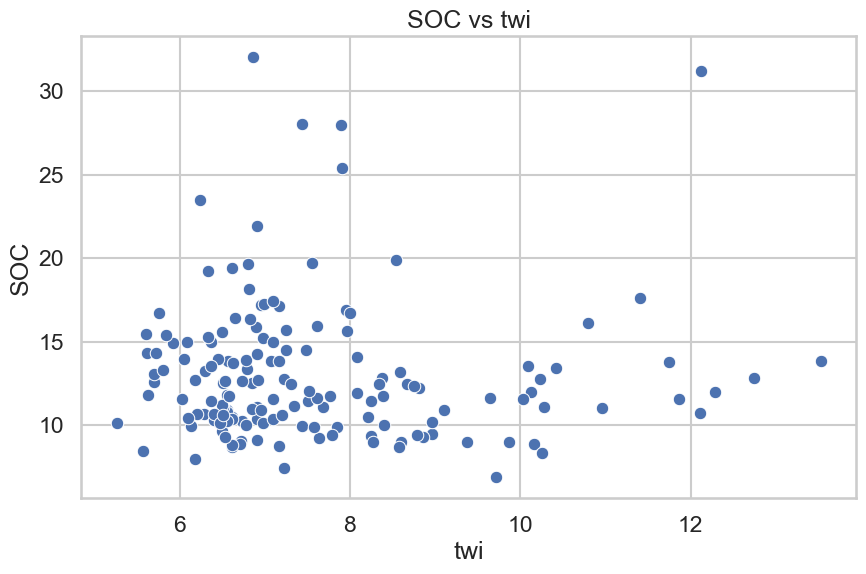

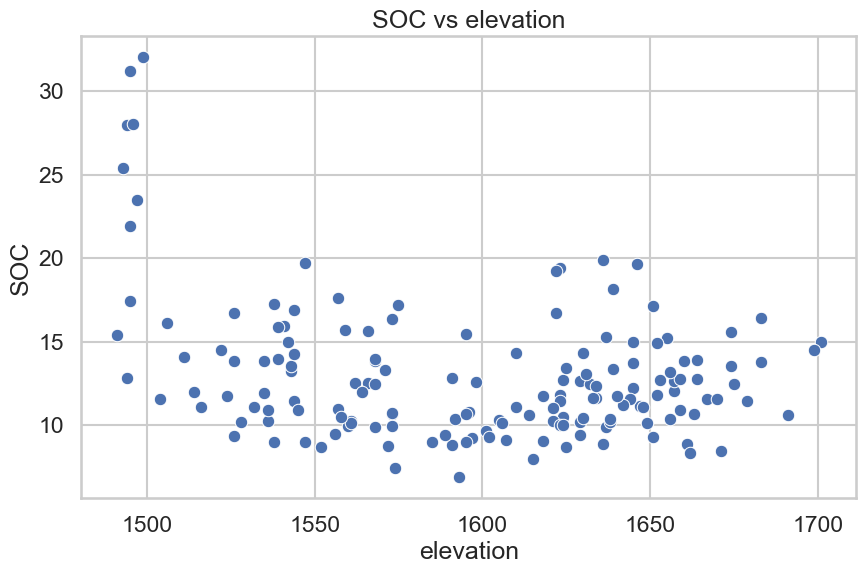

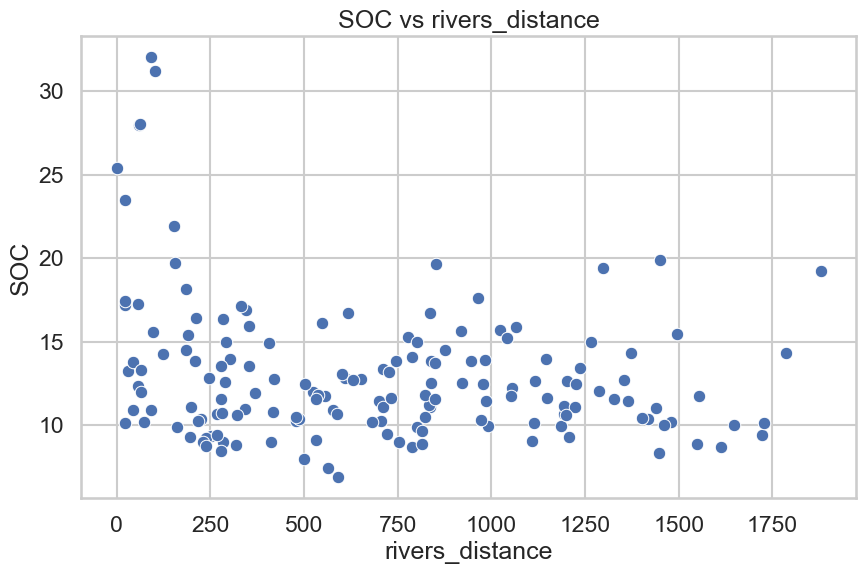

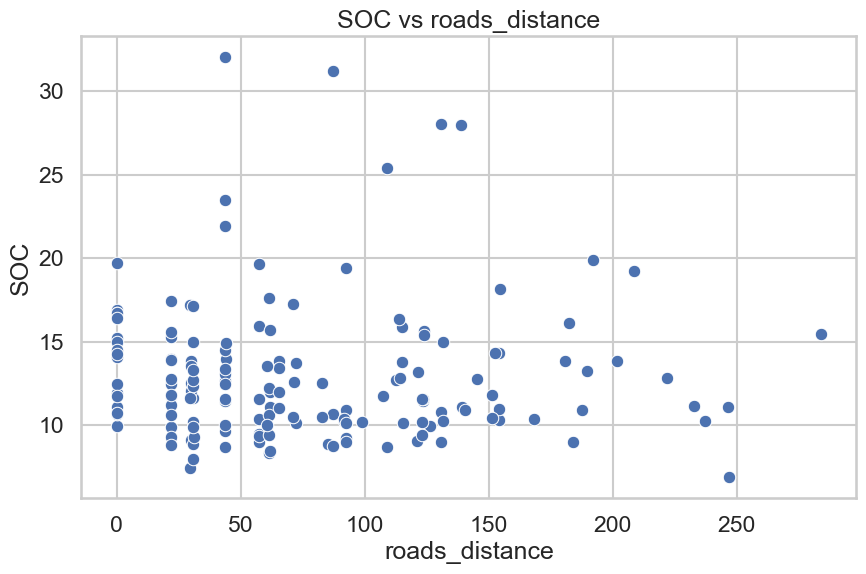

In [25]:
# Scatter plot of sampled data against SOC, iteratively 
# for each band
for band in sampled_data.drop(columns=['geometry', 'predSOC']).columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=sampled_data, x=band, y='predSOC')
    plt.title(f'SOC vs {band}')
    plt.xlabel(band)
    plt.ylabel('SOC')
    plt.show()

In [ ]:
import geopandas as gpd
from shapely.geometry import box

def get_extent_polygon(point_gdf):
    """
    Create a polygon representing the extent (bounding box) of a point GeoDataFrame.
    
    Parameters:
    -----------
    point_gdf : GeoDataFrame
        A GeoDataFrame containing point geometries
        
    Returns:
    --------
    GeoDataFrame
        A new GeoDataFrame containing a single polygon representing the extent
    """
    # Check if the input is a GeoDataFrame
    if not isinstance(point_gdf, gpd.GeoDataFrame):
        raise TypeError("Input must be a GeoDataFrame")
    
    # Check if the GeoDataFrame is empty
    if point_gdf.empty:
        raise ValueError("Input GeoDataFrame is empty")
    
    # Get the total bounds of the point GeoDataFrame
    # This returns (minx, miny, maxx, maxy)
    minx, miny, maxx, maxy = point_gdf.total_bounds
    
    # Create a box (rectangle) from the bounds
    extent_polygon = box(minx, miny, maxx, maxy)
    
    # Create a new GeoDataFrame with the extent polygon
    # Using the same CRS as the input GeoDataFrame
    extent_gdf = gpd.GeoDataFrame(geometry=[extent_polygon], crs=point_gdf.crs)
    
    return extent_gdf

# Example usage
# Assuming you have a point GeoDataFrame called 'point_gdf'
# point_gdf = ...
extent_gdf = get_extent_polygon(soc_gdf)
extent_gdf.to_file("./data/shp/extent_polygon.shp", driver='ESRI Shapefile')

#### Correlation


The objective here is to use the data obtained to find correlation in the data, including but not limited to Pearson Correlation, MORAN, spatial-autocorrelation

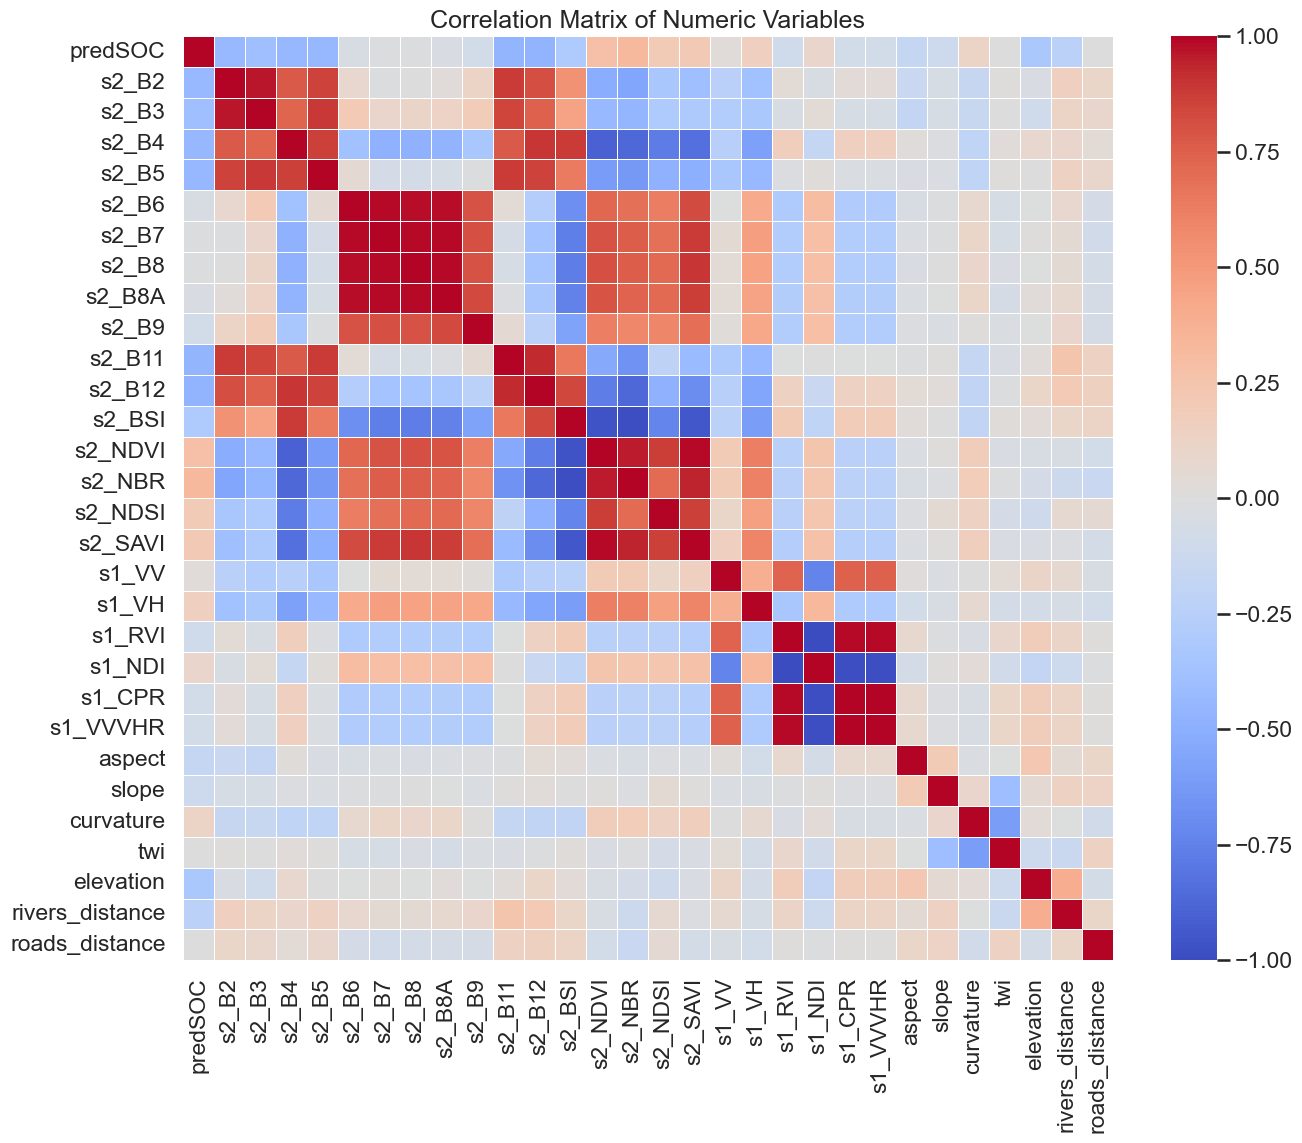

In [27]:
# 2. Select only numeric columns
numeric_data = sampled_data.select_dtypes(include=np.number)

# 3. Compute the correlation matrix
corr_matrix = numeric_data.corr()

# 4. Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Variables', fontsize=18)
plt.show()

In [32]:
import numpy as np
from scipy.spatial import distance_matrix

# Assume sampled_data is your GeoDataFrame
# Make sure it has:
# - geometry column
# - a variable of interest, e.g., 'total_count'

# 1. Extract the variable you want to test

y = sampled_data['predSOC'].values  # Replace with your column

# 2. Extract coordinates from the geometry
coords = np.array([(point.x, point.y) for point in sampled_data.geometry])

# 3. Compute pairwise distance matrix
dist_matrix = distance_matrix(coords, coords)

# 4. Inverse distance weights
np.fill_diagonal(dist_matrix, np.inf)  # Avoid division by zero
weights = 1 / dist_matrix

# 5. Row-standardize the weights
weights = weights / weights.sum(axis=1, keepdims=True)

# 6. Moran's I calculation
y_mean = np.mean(y)

# Numerator
num = 0
for i in range(len(y)):
    for j in range(len(y)):
        num += weights[i, j] * (y[i] - y_mean) * (y[j] - y_mean)

# Denominator
den = np.sum((y - y_mean)**2)

# Moran's I
moran_i = (len(y) / weights.sum()) * (num / den)

print(f"Moran's I: {moran_i:.4f}")


Moran's I: 0.1743


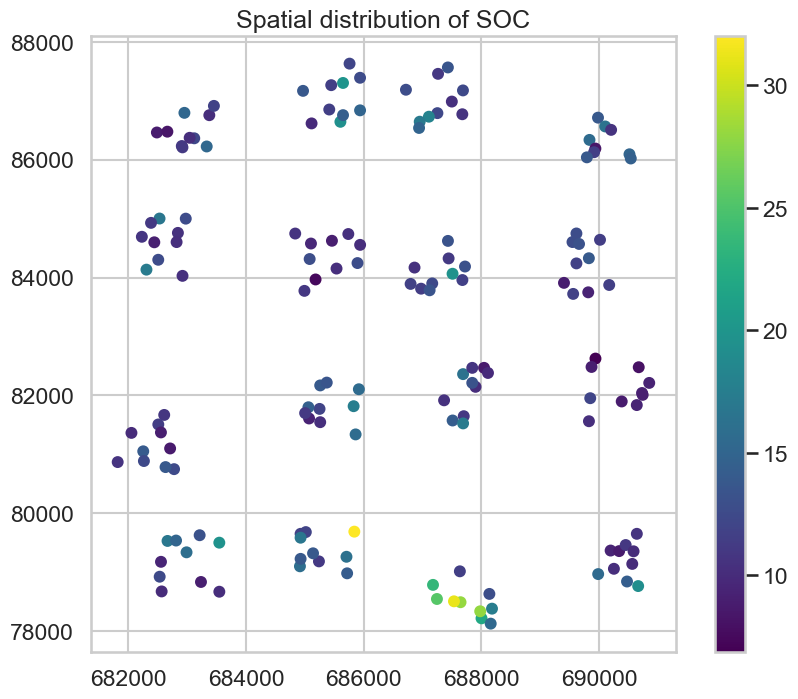

In [34]:
import matplotlib.pyplot as plt

# Plot sampled_data points colored by 'total_count'
fig, ax = plt.subplots(figsize=(10, 8))
sampled_data.plot(column='predSOC', cmap='viridis', legend=True, markersize=50, ax=ax)
plt.title('Spatial distribution of SOC')
plt.show()


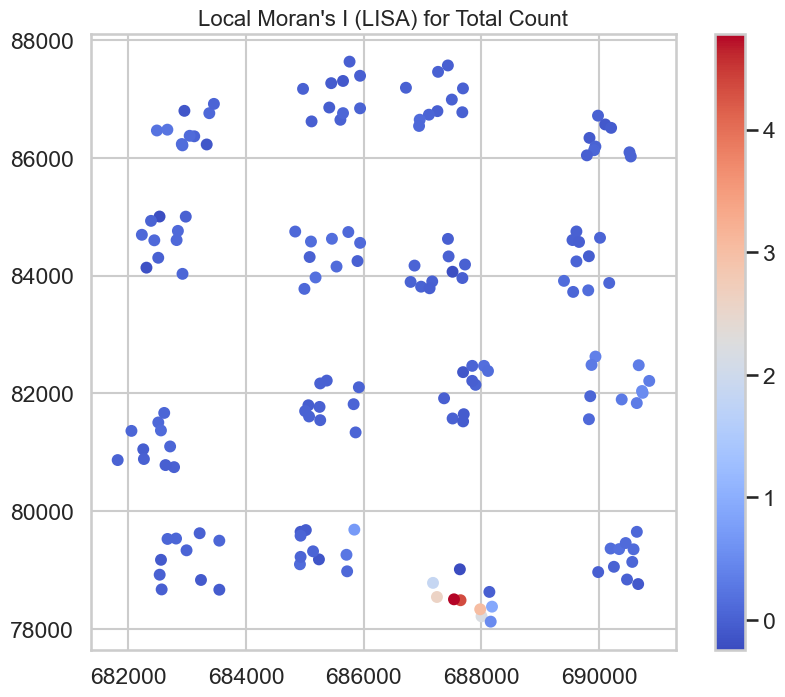

In [35]:
import numpy as np
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt
import geopandas as gpd

# Assume sampled_data exists and has a geometry column and a value column like 'total_count'

# 1. Extract coordinates and variable
coords = np.array([(point.x, point.y) for point in sampled_data.geometry])
y = sampled_data['predSOC'].values

# 2. Create distance matrix
dist_matrix = distance_matrix(coords, coords)

# 3. Inverse distance weights
np.fill_diagonal(dist_matrix, np.inf)
weights = 1 / dist_matrix

# 4. Row-standardize weights
weights = weights / weights.sum(axis=1, keepdims=True)

# 5. Mean and standardize y
y_mean = np.mean(y)
y_std = np.std(y)
z = (y - y_mean) / y_std  # Standardized values

# 6. Calculate Local Moran's I for each point
local_moran_i = []

for i in range(len(y)):
    zi = z[i]
    neighbors = weights[i, :]
    local_I = zi * np.sum(neighbors * z)
    local_moran_i.append(local_I)

local_moran_i = np.array(local_moran_i)

# 7. Attach Local Moran's I to your sampled_data
sampled_data['local_moran_I'] = local_moran_i

# 8. Plot Local Moran's I
fig, ax = plt.subplots(figsize=(10, 8))
sampled_data.plot(column='local_moran_I', cmap='coolwarm', legend=True, markersize=50, ax=ax)
plt.title("Local Moran's I (LISA) for Total Count", fontsize=16)
plt.show()


## Raster Alignment and CLipping

# Modeling

## Data Cleaning

## Training Model

In [72]:
modelling_data = sampled_data.copy()

# Drop the geometry column
X = modelling_data.drop(columns=['geometry', 'predSOC'])
y = modelling_data['predSOC']
X.shape, y.shape

((159, 29), (159,))

In [73]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Split (optional but good for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
print("Model R2 on test:", model.score(X_test, y_test))


Model R2 on test: 0.6276423183037332


## Prepare raster layers for prediction

In [74]:
import rasterio
import geopandas as gpd
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
import os
import numpy as np
from shapely.geometry import mapping
from pathlib import Path


In [ ]:

def clip_raster_with_geodataframe(input_raster, gdf, output_raster, all_touched=False):
    """
    Clips a raster using the geometries in a GeoDataFrame.
    
    Parameters:
    -----------
    input_raster : str
        Path to the input raster file
    gdf : geopandas.GeoDataFrame
        GeoDataFrame containing the clip geometry(s)
    output_raster : str
        Path to save the clipped raster
    all_touched : bool, optional
        If True, all pixels touched by the geometry are included
    """
    # Ensure the GeoDataFrame has the same CRS as the raster
    with rasterio.open(input_raster) as src:
        # Get the CRS of the raster
        raster_crs = src.crs
        
        # Project the GeoDataFrame to match the raster CRS if necessary
        if gdf.crs != raster_crs:
            gdf = gdf.to_crs(raster_crs)
        
        # Convert the GeoDataFrame geometries to GeoJSON-like format for masking
        geometries = [mapping(geom) for geom in gdf.geometry]
        
        # Perform the masking operation
        out_image, out_transform = mask(src, geometries, crop=True, all_touched=all_touched, nodata=src.nodata)
        
        # Update the metadata for the output raster
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
        
        # Write the clipped raster to disk
        with rasterio.open(output_raster, "w", **out_meta) as dest:
            dest.write(out_image)
            
    print(f"Raster clipped and saved to {output_raster}")
    return output_raster

def align_raster(input_raster, reference_raster, output_raster, resampling_method=Resampling.nearest):
    """
    Aligns a raster to match the CRS, resolution, and extent of a reference raster.
    
    Parameters:
    -----------
    input_raster : str
        Path to the input raster file
    reference_raster : str
        Path to the reference raster file
    output_raster : str
        Path to save the aligned raster
    resampling_method : Resampling, optional
        Method used for resampling during reprojection
    """
    # Open the input raster
    with rasterio.open(input_raster) as src:
        # Open the reference raster to get its metadata
        with rasterio.open(reference_raster) as reference:
            # Calculate the transformation parameters
            dst_transform, dst_width, dst_height = calculate_default_transform(
                src.crs, reference.crs,
                src.width, src.height,
                *src.bounds,
                dst_width=reference.width, dst_height=reference.height
            )
            
            # Update the metadata for the output raster
            dst_kwargs = src.meta.copy()
            dst_kwargs.update({
                'crs': reference.crs,
                'transform': dst_transform,
                'width': dst_width,
                'height': dst_height,
                'nodata': src.nodata if src.nodata is not None else 0
            })
            
            # Create the output raster
            with rasterio.open(output_raster, 'w', **dst_kwargs) as dst:
                # Reproject and save the data to the output raster
                for i in range(1, src.count + 1):
                    reproject(
                        source=rasterio.band(src, i),
                        destination=rasterio.band(dst, i),
                        src_transform=src.transform,
                        src_crs=src.crs,
                        dst_transform=dst_transform,
                        dst_crs=reference.crs,
                        resampling=resampling_method
                    )
                
    print(f"Raster aligned and saved to {output_raster}")
    return output_raster

def process_raster_collection(raster_dict, aoi_gdf, output_dir):
    """
    Process a collection of rasters using SRTM as reference:
    1. First clip the SRTM raster using the AOI GeoDataFrame
    2. Then align all other rasters to match the clipped SRTM
    
    Parameters:
    -----------
    raster_dict : dict
        Dictionary with raster names as keys and file paths as values
    aoi_gdf : geopandas.GeoDataFrame
        GeoDataFrame containing the AOI geometry(s)
    output_dir : str
        Directory to save the processed rasters
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Verify SRTM is in the dictionary
    if 'elevation' not in raster_dict:
        raise ValueError("SRTM raster not found in the raster dictionary")
    
    # First, clip the SRTM raster
    srtm_path = raster_dict['elevation']
    clipped_srtm_path = os.path.join(output_dir, "elevation-clipped.tif")
    
    print(f"Clipping SRTM raster...")
    clipped_srtm = clip_raster_with_geodataframe(srtm_path, aoi_gdf, clipped_srtm_path)
    
    # Use the clipped SRTM as reference for all other rasters
    processed_rasters = {'elevation': clipped_srtm}
    
    # Process all other rasters
    for name, path in raster_dict.items():
        if name != 'elevation':
            print(f"Processing {name} raster...")
            
            # Choose resampling method based on raster type
            if name.lower() in ['landcover', 'landuse', 'classification']:
                # Use nearest neighbor for categorical data
                resampling_method = Resampling.nearest
            else:
                # Use bilinear for continuous data
                resampling_method = Resampling.bilinear
            
            # Define output path
            output_path = os.path.join(output_dir, f"{name}-aligned.tif")
            
            # Align raster to clipped SRTM
            aligned_raster = align_raster(path, clipped_srtm, output_path, resampling_method)
            processed_rasters[name] = aligned_raster
    
    return processed_rasters

# Example usage
if __name__ == "__main__":
    # Define your raster dictionary
    raster_dict =  all_rasters
    
    aoi_gdf = extent_gdf.copy()
    
    # Define output directory
    output_dir = "./data/clipped_rs/"
    
    # Process all rasters
    processed_rasters = process_raster_collection(raster_dict, aoi_gdf, output_dir)
    
    print("\nProcessing completed. Summary:")
    for name, path in processed_rasters.items():
        print(f"{name}: {path}")

## Load Predictor Raster

In [ ]:
# Load all the rasters in a directory to a dict the name (first part of the name of the file, delimiter=_), path
def load_rasters_to_dict(directory, delimiter='-'):
    """
    Load all rasters in a directory into a dictionary.
    
    Parameters:
    -----------
    directory : str
        Path to the directory containing raster files
    delimiter : str, optional
        Delimiter used to split the filename for the key (default is '_')
        
    Returns:
    --------
    dict
        Dictionary with raster names as keys and file paths as values
    """
    raster_dict = {}
    
    # Iterate through all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith('.tif'):
            # Split the filename using the delimiter and take the first part as the key
            key = filename.split(delimiter)[0]
            raster_dict[key] = os.path.join(directory, filename)
    
    return raster_dict
# Example usage
raster_dict = load_rasters_to_dict('./data/clipped_rs/')
raster_dict


{'aspect': './clipped_rs/aspect-aligned.tif',
 'curvature': './clipped_rs/curvature-aligned.tif',
 'elevation': './clipped_rs/elevation-clipped.tif',
 'rivers_distance': './clipped_rs/rivers_distance-aligned.tif',
 'roads_distance': './clipped_rs/roads_distance-aligned.tif',
 's1_CPR': './clipped_rs/s1_CPR-aligned.tif',
 's1_NDI': './clipped_rs/s1_NDI-aligned.tif',
 's1_RVI': './clipped_rs/s1_RVI-aligned.tif',
 's1_VH': './clipped_rs/s1_VH-aligned.tif',
 's1_VV': './clipped_rs/s1_VV-aligned.tif',
 's1_VVVHR': './clipped_rs/s1_VVVHR-aligned.tif',
 's2_B11': './clipped_rs/s2_B11-aligned.tif',
 's2_B12': './clipped_rs/s2_B12-aligned.tif',
 's2_B2': './clipped_rs/s2_B2-aligned.tif',
 's2_B3': './clipped_rs/s2_B3-aligned.tif',
 's2_B4': './clipped_rs/s2_B4-aligned.tif',
 's2_B5': './clipped_rs/s2_B5-aligned.tif',
 's2_B6': './clipped_rs/s2_B6-aligned.tif',
 's2_B7': './clipped_rs/s2_B7-aligned.tif',
 's2_B8': './clipped_rs/s2_B8-aligned.tif',
 's2_B8A': './clipped_rs/s2_B8A-aligned.tif',
 '

In [79]:
# Open 
import rasterio
import numpy as np

# Initialize an empty list to hold each raster array
raster_arrays = []

# Loop through each raster file
for name, path in raster_dict.items():
    with rasterio.open(path) as src:
        array = src.read(1)  # Read first band
        raster_arrays.append(array)

        # Save metadata (only once, assuming all rasters are aligned)
        if 'profile' not in locals():
            profile = src.profile

# Stack into a 3D array: (height, width, n_features)
stack = np.stack(raster_arrays, axis=-1)


In [80]:
# Save shape for later
n_rows, n_cols, n_features = stack.shape

# Flatten to (n_pixels, n_features)
X_full = stack.reshape(-1, n_features)


In [81]:
# Example: assume nodata is very negative
nodata_mask = np.any(X_full < -9990, axis=1)

# Set nodata pixels to 0 or mean (or mask later after prediction)
X_full_clean = np.nan_to_num(X_full, nan=0)


## Predict To Raster

In [83]:
# Predict
predictions_flat = model.predict(X_full_clean)

# Set nodata predictions to np.nan (optional)
predictions_flat[nodata_mask] = np.nan

# Reshape back to raster grid
predictions = predictions_flat.reshape(n_rows, n_cols)


In [84]:
# Update profile for output (single band, float32)
profile.update(
    dtype=rasterio.float32,
    count=1
)

# Write to file
with rasterio.open('predicted_SOC.tif', 'w', **profile) as dst:
    dst.write(predictions.astype(rasterio.float32), 1)
